 # Algorithmic Day-Ahead BESS Optimization

 **Author:** Quantitative Developer Candidate



 **Objective:** # 1. Forecast Day-Ahead wholesale electricity prices using an XGBoost regressor with time-delay embeddings and rolling volatility features.

 2. Optimize the hyperparameters of the forecasting model using Optuna with Time-Series Cross Validation to prevent data leakage.

 3. Feed the out-of-sample price forecast into a Mixed-Integer Linear Program (MILP) to find the profit-maximizing physical dispatch schedule for a 10 MW / 20 MWh Battery Energy Storage System (BESS).

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
import pulp
import requests
import warnings
from datetime import datetime, timedelta
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import plotnine as p9
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')


c:\Users\david\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 ## 1. Feature Engineering & Mock Data Generation

 In production, this cell fetches data from the Energinet API. For this portfolio piece, we generate a synthetic, highly seasonal time-series reflecting the jump-diffusion and daily cyclicality of the DK2 power market.

In [ ]:
import numpy as np
import pandas as pd
import requests
from datetime import datetime, timedelta

class NordPoolDataPipeline:
    """
    Pipeline to fetch and engineer features for 15-minute Day-Ahead power prices from the Energinet API.
    Day-Ahead power prices 
    """
    
    def __init__(self, price_area='DK2', days_back=180, chunk_size=10000):
        self.price_area = price_area
        self.days_back = days_back
        self.chunk_size = chunk_size
        self.base_url = 'https://api.energidataservice.dk/dataset/DayAheadPrices'
        self.raw_data = None
        
    def fetch_data(self):
        """Fetches 15-minute MTU data using pagination."""
        print(f"Fetching {self.days_back} days of data for {self.price_area}...")
        
        end_date = datetime.now()
        start_date = end_date - timedelta(days=self.days_back)
        
        start_str = start_date.strftime('%Y-%m-%dT%H:%M')
        end_str = end_date.strftime('%Y-%m-%dT%H:%M')
        
        all_records = []
        offset = 0
        
        while True:
            params = {
                'start': start_str,
                'end': end_str,
                'filter': f'{{"PriceArea":["{self.price_area}"]}}',
                'sort': 'TimeDK ASC',
                'limit': self.chunk_size,
                'offset': offset
            }
            
            response = requests.get(self.base_url, params=params)
            response.raise_for_status()
            
            records = response.json().get('records', [])
            if not records:
                break
                
            all_records.extend(records)
            offset += self.chunk_size
            
            if len(records) < self.chunk_size:
                break
                
        df = pd.DataFrame(all_records)
        df = df[['TimeDK', 'DayAheadPriceDKK']].rename(
            columns={'TimeDK': 'timestamp', 'DayAheadPriceDKK': 'price'}
        )
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df.set_index('timestamp', inplace=True)
        
        # Ensure strict 15-minute frequency, forward-filling any missing API gaps
        df = df[~df.index.duplicated(keep='first')]
        self.raw_data = df.asfreq('15min').ffill()
        
        print(f"Fetch complete: {len(self.raw_data)} 15-minute blocks loaded.")
        return self
    
    def engineer_features(self, lag_days=[1, 2, 7], rolling_hours=[6, 24]):
        """Dynamically generates time, lag, and rolling volatility features."""
        if self.raw_data is None:
            raise ValueError("You must call fetch_data() before engineer_features().")
            
        print("Engineering features...")
        df = self.raw_data.copy()
        
        # 1. Cyclical Time Encodings (15-min precision)
        time_of_day = df.index.hour + (df.index.minute / 60.0)
        df['time_sin'] = np.sin(2 * np.pi * time_of_day / 24)
        df['time_cos'] = np.cos(2 * np.pi * time_of_day / 24)
        df['day_of_week'] = df.index.dayofweek
        
        # 2. Dynamic Lags (96 blocks per day)
        for days in lag_days:
            blocks = days * 96
            df[f'lag_{days}d'] = df['price'].shift(blocks)
            
        # 3. Dynamic Rolling Statistics (Volatility & Momentum)
        for hours in rolling_hours:
            blocks = hours * 4
            # Standard metrics
            df[f'roll_mean_{hours}h'] = df['price'].rolling(window=blocks).mean()
            df[f'roll_std_{hours}h'] = df['price'].rolling(window=blocks).std()
            df[f'roll_max_{hours}h'] = df['price'].rolling(window=blocks).max()
            df[f'roll_min_{hours}h'] = df['price'].rolling(window=blocks).min()
            
            # Exponentially Weighted Moving Average (EWMA)
            df[f'ewma_{hours}h'] = df['price'].ewm(span=blocks, adjust=False).mean()
            
        # Drop NaN rows created by the longest lag
        df.dropna(inplace=True)
        print(f"Feature engineering complete. DataFrame shape: {df.shape}")
        
        return df

# ==========================================
# USAGE EXAMPLE (How clean your main script becomes)
# ==========================================
# Instantiate the pipeline
pipeline = NordPoolDataPipeline(price_area='DK2', days_back=180)

# Chain the methods to fetch and build the dataset in two lines of code
df_model_ready = pipeline.fetch_data().engineer_features(
    lag_days=[1, 2, 3, 7],         # Automatically builds 1d, 2d, 3d, 7d lags
    rolling_hours=[3, 12, 24, 48]  # Automatically builds stats for these hour windows
)

# Extract X and y for XGBoost
target = 'price'
features = [col for col in df_model_ready.columns if col != target]

X = df_model_ready[features]
y = df_model_ready[target]

Fetching 180 days of data for DK2...
Fetch complete: 17280 15-minute blocks loaded.
Engineering features...
Feature engineering complete. DataFrame shape: (16608, 28)


In [ ]:
df_model_ready.head()

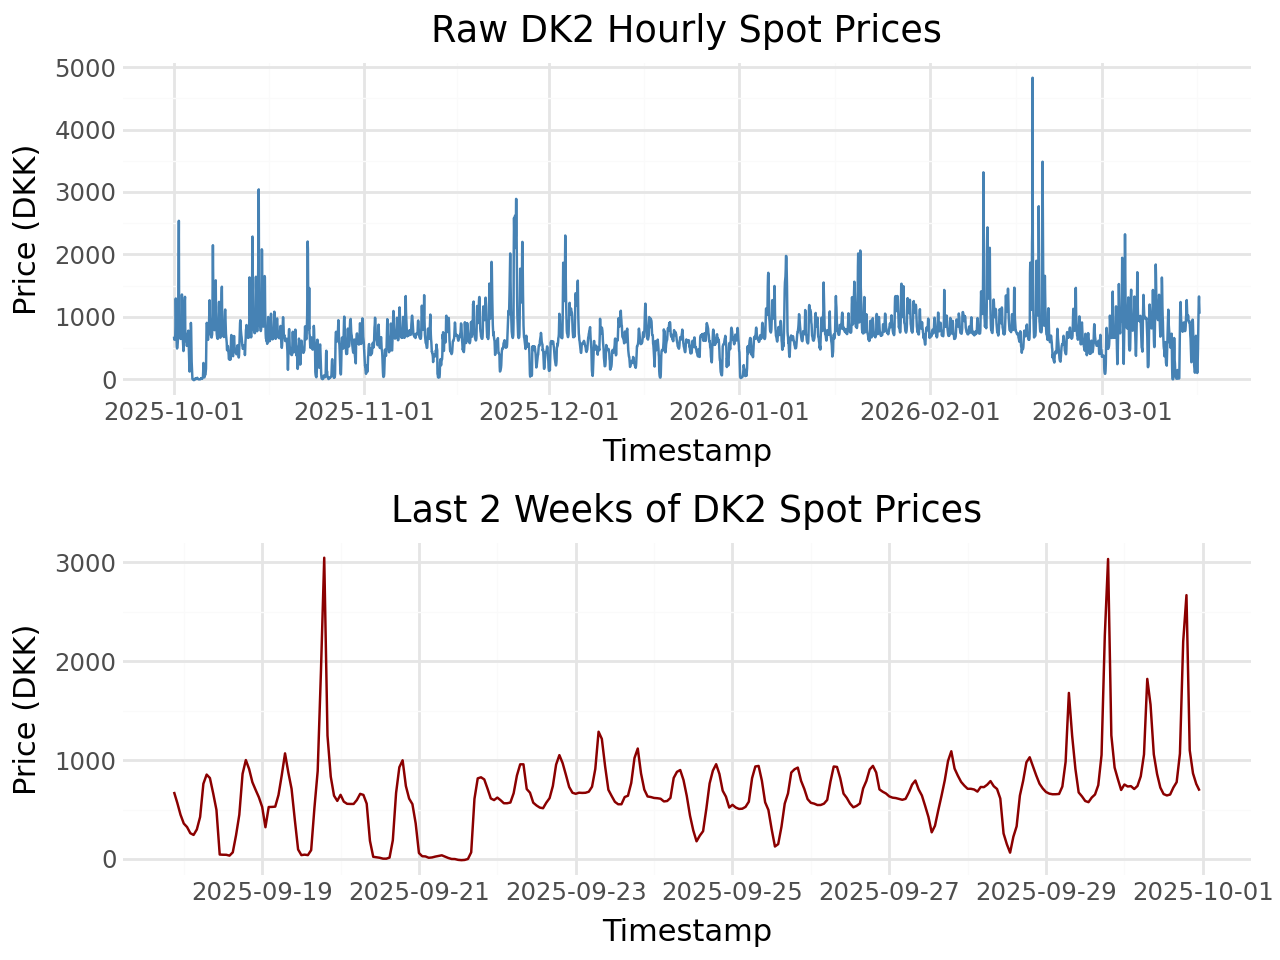

In [ ]:
# Visualize the raw hourly spot prices with plotnine
plot_raw = (
    p9.ggplot(df_raw.reset_index(), p9.aes(x="timestamp", y="price"))
    + p9.geom_line(color="steelblue")
    + p9.labs(
        title="Raw DK2 Hourly Spot Prices",
        x="Timestamp",
        y="Price (DKK)"
    )
    + p9.theme_minimal()
)

# Create a plot for the last two weeks of raw data
plot_last_2w = (
    p9.ggplot(last_2w.reset_index(), p9.aes(x="timestamp", y="price"))
    + p9.geom_line(color="darkred")
    + p9.labs(
        title="Last 2 Weeks of DK2 Spot Prices",
        x="Timestamp",
        y="Price (DKK)"
    )
    + p9.theme_minimal()
)

# Combine both plots in a grid (2 columns)
grid = (plot_raw / plot_last_2w)
grid

 ## 2. Optuna Hyperparameter Tuning

 We use Optuna to find the optimal tree depth and learning rate. Crucially, we use `TimeSeriesSplit` to respect the chronological order of the data, preventing future data from leaking into past training folds.

In [ ]:
# %% [markdown]
# ## 2. Optuna Hyperparameter Tuning (15-Minute Resolution)
# We tune the XGBoost model using Time-Series Cross Validation. 
# Because the European market now operates on 15-minute Market Time Units (MTUs), 
# a full 24-hour Day-Ahead forecast requires predicting exactly 96 blocks.

# %%
# Define our forecasting horizon: 24 hours = 96 blocks (15-min each)
forecast_horizon = 96

# Hold out the very last 96 blocks as our pure out-of-sample prediction test for tomorrow
X_train, X_test = X.iloc[:-forecast_horizon], X.iloc[-forecast_horizon:]
y_train, y_test = y.iloc[:-forecast_horizon], y.iloc[-forecast_horizon:]

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400), # Increased max trees for higher-frequency data
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'objective': 'reg:squarederror',
        'random_state': 42
    }
    
    # 3-fold cross validation respecting the arrow of time
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        preds = model.predict(X_val)
        
        # Calculate RMSE for this fold
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

print(f"\n--- Running Optuna Optimization on 15-min Data ({len(X_train)} training rows) ---")
# Set n_trials=15 for the portfolio script; a production desk would let this run for hundreds of trials
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)

print("Best Parameters:", study.best_params)
print(f"Best CV RMSE: {study.best_value:.2f} DKK")

# %% [markdown]
# ## 3. Final 96-Block Model Training & Forecasting
# We train the final XGBoost model using the optimal hyperparameters and generate the 
# 96 discrete 15-minute price predictions that the optimization solver needs to bid tomorrow.

# %%
print("\n--- Training Final 15-Min XGBoost Model ---")
best_model = xgb.XGBRegressor(**study.best_params, objective='reg:squarederror', random_state=42)
best_model.fit(X_train, y_train)

# Forecast the out-of-sample 96 blocks
forecasted_prices = best_model.predict(X_test)
actual_prices = y_test.values

test_rmse = np.sqrt(mean_squared_error(actual_prices, forecasted_prices))
print(f"Out-of-Sample 96-Block Forecast RMSE: {test_rmse:.2f} DKK")

# Create a clean DataFrame for the optimizer, mapping the 96 blocks back to their timestamps
df_tomorrow = pd.DataFrame({
    'Timestamp': X_test.index,
    'Block_Index': np.arange(forecast_horizon), # 0 to 95
    'Forecasted_Price_DKK': np.round(forecasted_prices, 2),
    'Actual_Price_DKK': np.round(actual_prices, 2)
})

print("\nForecast Snapshot (First 5 15-minute blocks):")
print(df_tomorrow[['Timestamp', 'Forecasted_Price_DKK', 'Actual_Price_DKK']].head())

[I 2026-03-16 22:18:08,713] A new study created in memory with name: no-name-630e5737-c020-409f-94e4-e39eb362e0d9



--- Running Optuna Optimization on 15-min Data (15255 training rows) ---


[I 2026-03-16 22:18:12,555] Trial 0 finished with value: 127.63979949171971 and parameters: {'n_estimators': 399, 'max_depth': 6, 'learning_rate': 0.13672282390154317, 'subsample': 0.7079524477934602, 'colsample_bytree': 0.8445030364660502}. Best is trial 0 with value: 127.63979949171971.
[I 2026-03-16 22:18:17,579] Trial 1 finished with value: 127.30978306208128 and parameters: {'n_estimators': 399, 'max_depth': 9, 'learning_rate': 0.13962546150135818, 'subsample': 0.6983045864217824, 'colsample_bytree': 0.6974565548279424}. Best is trial 1 with value: 127.30978306208128.
[I 2026-03-16 22:18:19,248] Trial 2 finished with value: 124.95921119705065 and parameters: {'n_estimators': 87, 'max_depth': 9, 'learning_rate': 0.04089594489467526, 'subsample': 0.9871743235495744, 'colsample_bytree': 0.6082380272000896}. Best is trial 2 with value: 124.95921119705065.
[I 2026-03-16 22:18:20,506] Trial 3 finished with value: 122.56723952903683 and parameters: {'n_estimators': 259, 'max_depth': 4, '

Best Parameters: {'n_estimators': 259, 'max_depth': 4, 'learning_rate': 0.07928447582888386, 'subsample': 0.7060270130418909, 'colsample_bytree': 0.8416892753401912}
Best CV RMSE: 122.57 DKK

--- Training Final 15-Min XGBoost Model ---
Out-of-Sample 96-Block Forecast RMSE: 93.77 DKK

Forecast Snapshot (First 5 15-minute blocks):
            Timestamp  Forecasted_Price_DKK  Actual_Price_DKK
0 2026-03-15 21:45:00            662.469971            537.06
1 2026-03-15 22:00:00            683.559998            612.53
2 2026-03-15 22:15:00            653.330017            584.51
3 2026-03-15 22:30:00            638.900024            561.34
4 2026-03-15 22:45:00            585.539978            515.16


In [ ]:
# %% [markdown]
# ## 2b. Baseline Model: ARIMAX Optimization with Optuna
# To prove the value of the XGBoost model, we benchmark it against a classical ARIMAX 
# (Auto-Regressive Integrated Moving Average with Exogenous Variables) model.
# We utilize the cyclical time encodings as our exogenous features.

# %%
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress statsmodels convergence warnings during hyperparameter search
warnings.filterwarnings("ignore", module="statsmodels")

print("\n--- Initializing ARIMAX Baseline Pipeline ---")

# Define forecasting horizon: 24 hours = 96 blocks (15-min each)
forecast_horizon = 96

# For ARIMAX, we only use perfectly future-known deterministic features
exog_features = ['time_sin', 'time_cos', 'day_of_week']
X_arimax = df_model_ready[exog_features]
y_arimax = df_model_ready['price']

# TRUNCATION: ARIMA MLE optimization is computationally massive. 
# We restrict the training data to the most recent 14 days (1344 blocks) 
# prior to our test set to make the hyperparameter search mathematically tractable.
lookback_window = 14 * 96 
split_index = len(df_model_ready) - forecast_horizon

X_train_ari = X_arimax.iloc[split_index - lookback_window : split_index]
y_train_ari = y_arimax.iloc[split_index - lookback_window : split_index]

X_test_ari = X_arimax.iloc[split_index:]
y_test_ari = y_arimax.iloc[split_index:]

def arima_objective(trial):
    # Suggest ARIMA parameters: (p, d, q)
    # Keeping bounds relatively small to ensure convergence and prevent extreme compute times
    p = trial.suggest_int('p', 1, 4)  # Auto-regressive order
    d = trial.suggest_int('d', 0, 1)  # Differencing order (integration)
    q = trial.suggest_int('q', 1, 4)  # Moving-average order
    
    # We use a smaller TimeSeriesSplit for the ARIMA benchmark
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_train_ari):
        X_tr, X_val = X_train_ari.iloc[train_idx], X_train_ari.iloc[val_idx]
        y_tr, y_val = y_train_ari.iloc[train_idx], y_train_ari.iloc[val_idx]
        
        try:
            # Fit ARIMAX model
            model = ARIMA(endog=y_tr, exog=X_tr, order=(p, d, q))
            fitted_model = model.fit(method='statespace')
            
            # Forecast
            preds = fitted_model.forecast(steps=len(y_val), exog=X_val)
            rmse = np.sqrt(mean_squared_error(y_val, preds))
            cv_scores.append(rmse)
        except Exception as e:
            # If the specific (p,d,q) combination fails to converge, heavily penalize it
            return float('inf')
            
    return np.mean(cv_scores) if cv_scores else float('inf')

print(f"Running Optuna Optimization for ARIMAX on last {lookback_window} blocks...")
# Set n_trials=10. Even with truncation, ARIMA optimization is heavy.
arima_study = optuna.create_study(direction='minimize')
arima_study.optimize(arima_objective, n_trials=10)

print("Best ARIMAX Parameters:", arima_study.best_params)
print(f"Best ARIMAX CV RMSE: {arima_study.best_value:.2f} DKK")

# %% [markdown]
# ## 3b. Final ARIMAX Training & Forecasting
# We train the optimal ARIMAX model to generate our 96-block baseline forecast.

# %%
print("\n--- Training Final 96-Block ARIMAX Model ---")
best_p = arima_study.best_params['p']
best_d = arima_study.best_params['d']
best_q = arima_study.best_params['q']

final_arima = ARIMA(endog=y_train_ari, exog=X_train_ari, order=(best_p, best_d, best_q))
fitted_final_arima = final_arima.fit()

# Forecast the 96 out-of-sample blocks, feeding it the known future exogenous features
arima_forecasted_prices = fitted_final_arima.forecast(steps=forecast_horizon, exog=X_test_ari)
actual_prices_ari = y_test_ari.values

arima_test_rmse = np.sqrt(mean_squared_error(actual_prices_ari, arima_forecasted_prices))
print(f"Out-of-Sample ARIMAX Forecast RMSE: {arima_test_rmse:.2f} DKK")

# Compare against XGBoost
print("\n--- Model Benchmark Results ---")
print(f"XGBoost RMSE: {test_rmse:.2f} DKK")
print(f"ARIMAX RMSE:  {arima_test_rmse:.2f} DKK")

# Create a clean DataFrame comparing both forecasts to actuals
df_benchmark = pd.DataFrame({
    'Timestamp': X_test_ari.index,
    'Block_Index': np.arange(forecast_horizon),
    'Actual_Price_DKK': np.round(actual_prices_ari, 2),
    'XGBoost_Forecast': np.round(forecasted_prices, 2), # from the previous XGBoost block
    'ARIMAX_Forecast': np.round(arima_forecasted_prices.values, 2)
})

print("\nBenchmark Snapshot (First 5 15-minute blocks):")
print(df_benchmark[['Timestamp', 'Actual_Price_DKK', 'XGBoost_Forecast', 'ARIMAX_Forecast']].head())

[I 2026-03-16 22:24:40,139] A new study created in memory with name: no-name-9e6a9e13-07e2-4693-8933-b85fbcd539fe



--- Initializing ARIMAX Baseline Pipeline ---
Running Optuna Optimization for ARIMAX on last 1344 blocks...


[I 2026-03-16 22:24:43,345] Trial 0 finished with value: 373.6536608725548 and parameters: {'p': 3, 'd': 0, 'q': 2}. Best is trial 0 with value: 373.6536608725548.
[I 2026-03-16 22:24:44,695] Trial 1 finished with value: 353.6526636832425 and parameters: {'p': 3, 'd': 1, 'q': 1}. Best is trial 1 with value: 353.6526636832425.
[I 2026-03-16 22:24:47,376] Trial 2 finished with value: 375.3614642999196 and parameters: {'p': 3, 'd': 0, 'q': 4}. Best is trial 1 with value: 353.6526636832425.
[I 2026-03-16 22:24:49,084] Trial 3 finished with value: 364.8031912126384 and parameters: {'p': 4, 'd': 0, 'q': 1}. Best is trial 1 with value: 353.6526636832425.
[I 2026-03-16 22:24:51,817] Trial 4 finished with value: 363.05922555214846 and parameters: {'p': 3, 'd': 0, 'q': 3}. Best is trial 1 with value: 353.6526636832425.
[I 2026-03-16 22:24:54,156] Trial 5 finished with value: 373.6536608725548 and parameters: {'p': 3, 'd': 0, 'q': 2}. Best is trial 1 with value: 353.6526636832425.
[I 2026-03-16 2

Best ARIMAX Parameters: {'p': 1, 'd': 1, 'q': 2}
Best ARIMAX CV RMSE: 353.62 DKK

--- Training Final 96-Block ARIMAX Model ---
Out-of-Sample ARIMAX Forecast RMSE: 372.26 DKK

--- Model Benchmark Results ---
XGBoost RMSE: 93.77 DKK
ARIMAX RMSE:  372.26 DKK

Benchmark Snapshot (First 5 15-minute blocks):
            Timestamp  Actual_Price_DKK  XGBoost_Forecast  ARIMAX_Forecast
0 2026-03-15 21:45:00            537.06        662.469971           637.65
1 2026-03-15 22:00:00            612.53        683.559998           638.77
2 2026-03-15 22:15:00            584.51        653.330017           638.26
3 2026-03-15 22:30:00            561.34        638.900024           637.04
4 2026-03-15 22:45:00            515.16        585.539978           635.07


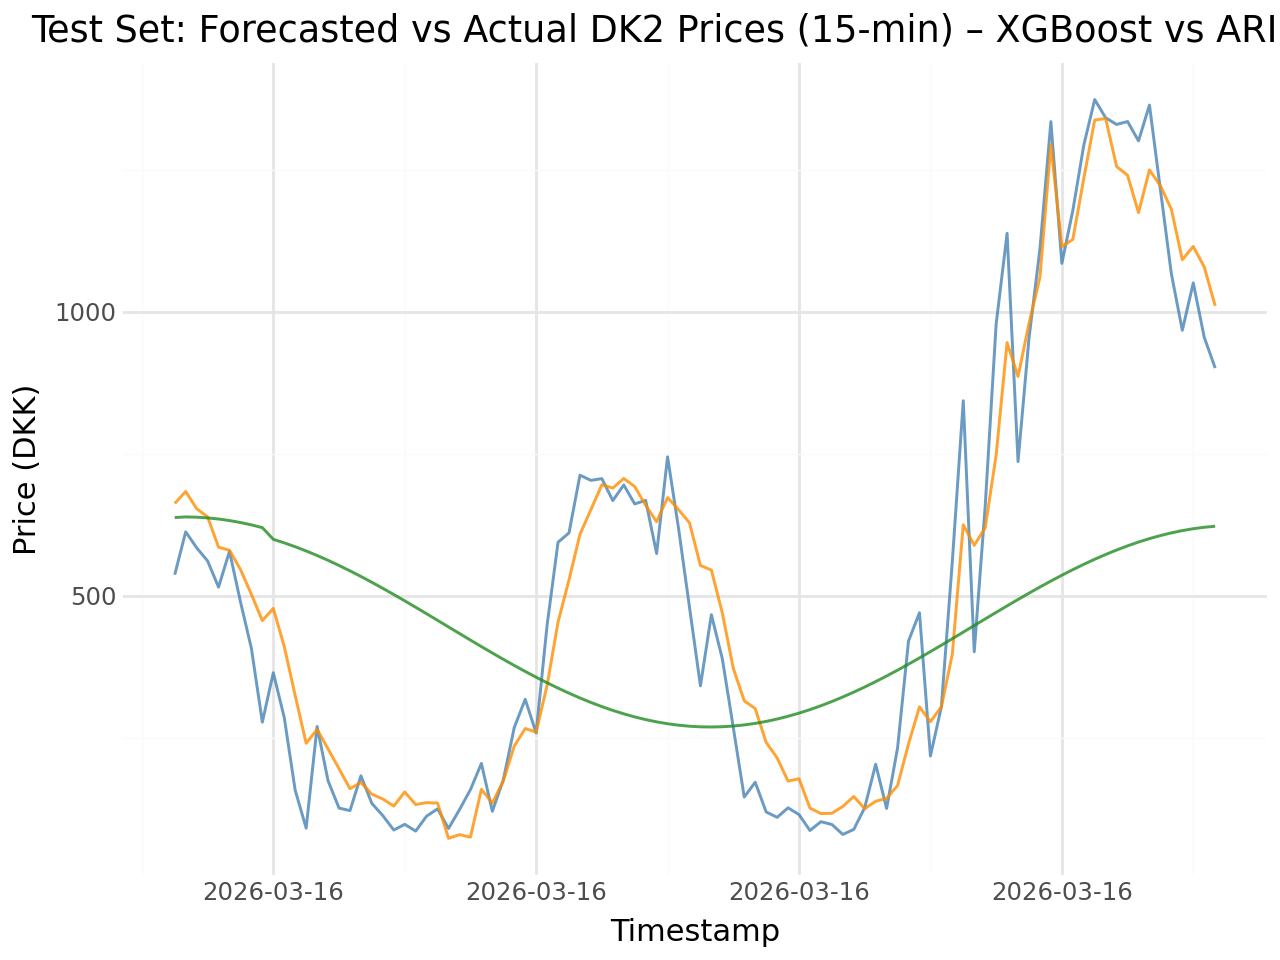

In [ ]:
# Add the ARIMAX forecast to the test-set dataframe and plot both model forecasts vs actuals
df_test_with_arima = X_test.copy()
df_test_with_arima["XGB_Predicted"] = best_model.predict(df_test_with_arima)
df_test_with_arima["ARIMAX_Predicted"] = arima_forecasted_prices
df_test_with_arima["Actual_Price"] = y_test

plot_pred_vs_actual_with_arima = (
    p9.ggplot(df_test_with_arima.reset_index(), p9.aes(x="timestamp"))
    + p9.geom_line(p9.aes(y="Actual_Price"), color="steelblue", size=0.6, alpha=0.8)
    + p9.geom_line(p9.aes(y="XGB_Predicted"), color="darkorange", size=0.6, alpha=0.8)
    + p9.geom_line(p9.aes(y="ARIMAX_Predicted"), color="forestgreen", size=0.6, alpha=0.8)
    + p9.labs(
        title="Test Set: Forecasted vs Actual DK2 Prices (15-min) – XGBoost vs ARIMAX",
        x="Timestamp",
        y="Price (DKK)"
    )
    + p9.theme_minimal()
)

plot_pred_vs_actual_with_arima

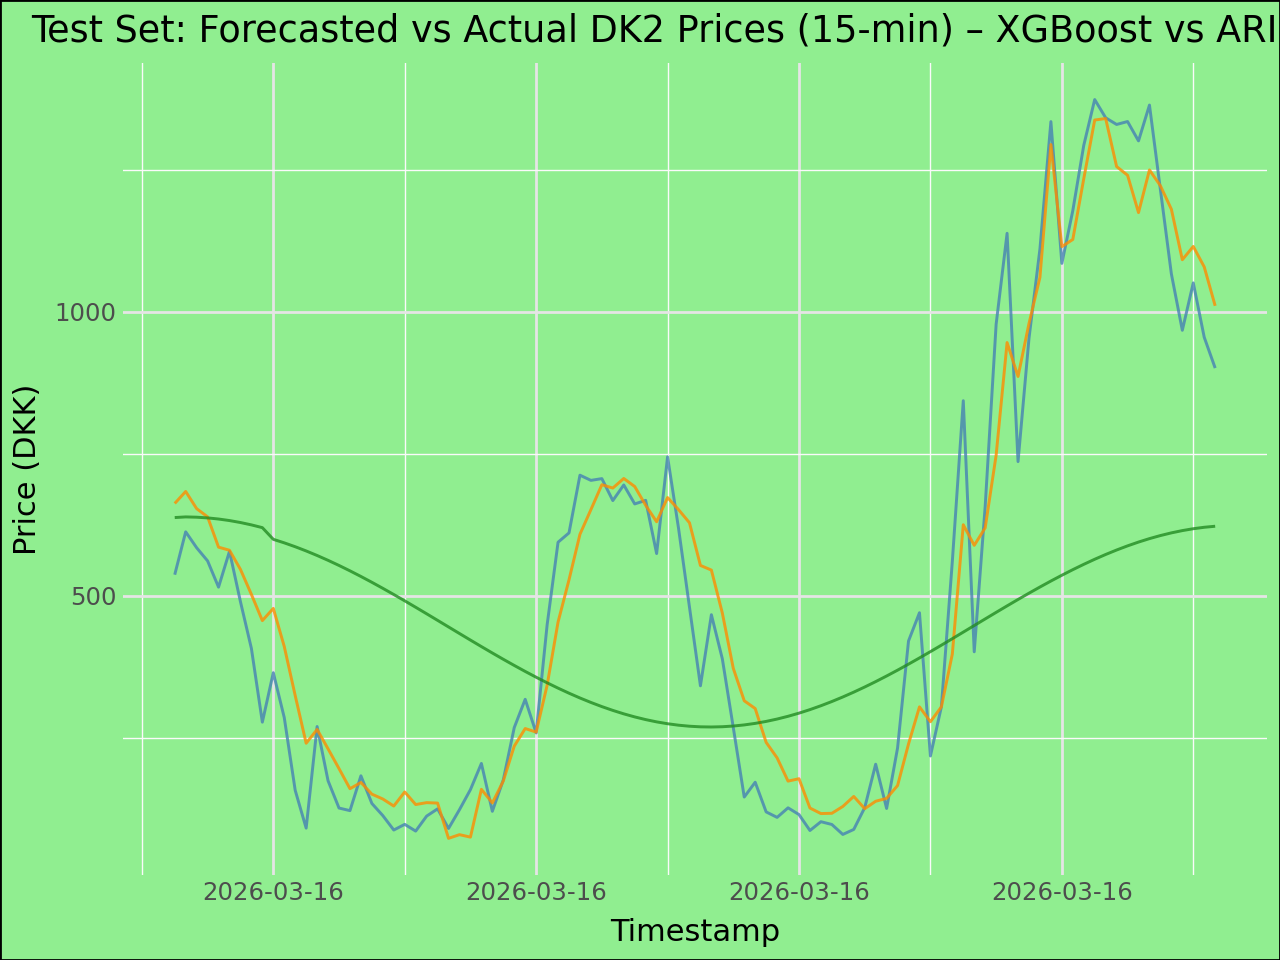

 ## 3. Final Model Training & Forecasting

 We train the final XGBoost model on the entire training set using the optimized hyperparameters, and predict the Day-Ahead auction clearing prices for tomorrow.

In [ ]:
print("\n--- Training Final XGBoost Model ---")
best_model = xgb.XGBRegressor(**study.best_params, objective='reg:squarederror', random_state=42)
best_model.fit(X_train, y_train)

# Forecast the next 24 hours
forecasted_prices = best_model.predict(X_test)
actual_prices = y_test.values

test_rmse = np.sqrt(mean_squared_error(actual_prices, forecasted_prices))
print(f"Out-of-Sample Forecast RMSE: {test_rmse:.2f} DKK")

# Create a clean DataFrame for the optimizer
df_tomorrow = pd.DataFrame({
    'Hour': np.arange(24),
    'Forecasted_Price_DKK': np.round(forecasted_prices, 2),
    'Actual_Price_DKK': np.round(actual_prices, 2)
})
print("\nForecast Snapshot (First 5 hours):")
print(df_tomorrow.head())



--- Training Final XGBoost Model ---
Out-of-Sample Forecast RMSE: 31.00 DKK

Forecast Snapshot (First 5 hours):
   Hour  Forecasted_Price_DKK  Actual_Price_DKK
0     0             85.220001             73.30
1     1            100.760002            114.69
2     2            128.649994             97.26
3     3            126.769997            127.82
4     4            193.399994            170.98


 ## 4. Mixed-Integer Linear Programming (MILP) BESS Optimization

 We take the 24-hour forecasted price vector and feed it into a PuLP solver. We introduce binary variables ($u_t, v_t$) to enforce mutual exclusivity, preventing the solver from mathematically hallucinating simultaneous charging and discharging during negative price events.

In [ ]:
print("\n--- Running MILP BESS Optimization ---")

# Hardware Parameters (10 MW / 20 MWh Battery)
T = 24
P_max = 10.0   
E_max = 20.0   
eta_c = 0.95   
eta_d = 0.95   

prob = pulp.LpProblem("Day_Ahead_BESS_Arbitrage", pulp.LpMaximize)

# Decision Variables
C = pulp.LpVariable.dicts("Charge", range(T), lowBound=0, upBound=P_max, cat='Continuous')
D = pulp.LpVariable.dicts("Discharge", range(T), lowBound=0, upBound=P_max, cat='Continuous')
SoC = pulp.LpVariable.dicts("SoC", range(T), lowBound=0, upBound=E_max, cat='Continuous')
u = pulp.LpVariable.dicts("Is_Charging", range(T), cat='Binary')
v = pulp.LpVariable.dicts("Is_Discharging", range(T), cat='Binary')

# Objective Function: Maximize Expected Arbitrage Profit
prob += pulp.lpSum([forecasted_prices[t] * (D[t] - C[t]) for t in range(T)])

# Constraints formulation
for t in range(T):
    # 1. State of Charge Tracking
    if t == 0:
        prob += SoC[t] == 0 + (C[t] * eta_c - D[t] / eta_d) 
    else:
        prob += SoC[t] == SoC[t-1] + (C[t] * eta_c - D[t] / eta_d)
    
    # 2. Big-M linking constraints (Continuous power bound to Binary state)
    prob += C[t] <= P_max * u[t]
    prob += D[t] <= P_max * v[t]
    
    # 3. Mutual exclusivity
    prob += u[t] + v[t] <= 1

# Solve the MILP
prob.solve(pulp.PULP_CBC_CMD(msg=False))



--- Running MILP BESS Optimization ---


1

 ## 5. Results & Bid Curve Extraction

 Extract the optimized schedule to construct the final bidding curve for the Nord Pool API.

In [ ]:
print(f"Solver Status: {pulp.LpStatus[prob.status]}")
print(f"Expected Day-Ahead Profit: {pulp.value(prob.objective):,.2f} DKK\n")

print("--- Final Algorithmic Dispatch Schedule ---")
results = []
for t in range(T):
    charge_val = C[t].varValue
    discharge_val = D[t].varValue
    soc_val = SoC[t].varValue
    
    action = "IDLE"
    volume = 0.0
    if charge_val > 0.1:
        action = "BUY (Charge)"
        volume = charge_val
    elif discharge_val > 0.1:
        action = "SELL (Discharge)"
        volume = discharge_val
        
    results.append({
        "Hour": t,
        "Forecast_Price": forecasted_prices[t],
        "Action": action,
        "Volume_MW": volume,
        "SoC_MWh": soc_val
    })

df_results = pd.DataFrame(results)
# Displaying only active trading hours to save space
active_trades = df_results[df_results['Action'] != "IDLE"]
print(active_trades.to_string(index=False))

Solver Status: Optimal
Expected Day-Ahead Profit: 5,672.71 DKK

--- Final Algorithmic Dispatch Schedule ---
 Hour  Forecast_Price           Action  Volume_MW   SoC_MWh
    0       85.216751     BUY (Charge)  10.000000  9.500000
    1      100.755280     BUY (Charge)  10.000000 19.000000
    3      126.772507     BUY (Charge)   1.052632 20.000000
   11      401.715210 SELL (Discharge)   9.000000 10.526316
   12      405.044312 SELL (Discharge)  10.000000  0.000000
